# Implementation of MCP Neuron for AND and OR Function.

In [7]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)
  sums = [x1 + x2 for x1, x2 in zip(X1, X2)]
  state_neuron = []
  for s in sums:
      state_neuron.append(1 if s >= T else 0)

  return state_neuron

In [8]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [9]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)
    sums = [x1 + x2 for x1, x2 in zip(X1, X2)]
    state_neuron = []
    for s in sums:
        state_neuron.append(1 if s >= T else 0)

    return state_neuron

In [10]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


### Answers: Task 1 Questions

**Question 1: List out all the limitations of MCP neurons.**
- MCP uses fixed/manual thresholds and does not learn from data.
- It models only very simple logic and has no weight adaptation.
- It cannot represent linearly inseparable problems (for example XOR with a single neuron).
- It has a binary step output only, so it is not suitable for smooth decision boundaries.
- It is not robust to noisy real-valued data compared to trainable models.

**Question 2: Can you develop logic for XOR using MCP?**
- A single MCP neuron cannot solve XOR because XOR is not linearly separable.
- XOR can be implemented using a small network of MCP-like units (multi-layer logic), but not by a single MCP if-else rule based on one thresholded sum.

# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset (file is in the same folder as this notebook)
df_0_1 = pd.read_csv("/content/drive/MyDrive/dataset/Copy of mnist_0_and_1.csv")

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


### Answers: Dataset Shape Questions

**Question 1: What does the shape of X represent?**
- `X.shape` is `(number_of_samples, number_of_features)`.
- In this MNIST subset, features are pixel values, so the number of features is 784 (28x28 image flattened).

**Question 2: What does the shape of y represent?**
- `y.shape` is `(number_of_samples,)`, meaning one class label per image.

### Viewing the Dataset.

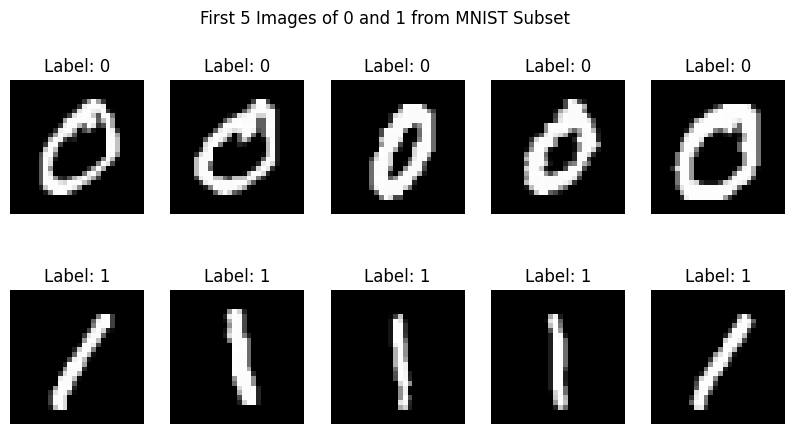

In [12]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [13]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

### Answers: Weight Initialization Questions

**Question 3: What does the weights array represent?**
- Each weight corresponds to one input feature (one pixel).
- Its value indicates how strongly that pixel contributes to predicting class 0 vs 1.

**Question 4: Why initialize weights to zero? What effect can it have?**
- Zero initialization is simple and works for perceptron because updates happen from data-driven errors.
- After first mistakes, weights diverge from zero and the model learns a separating boundary.
- For deeper neural networks, all-zero initialization can cause symmetry issues, but for single-layer perceptron it is acceptable.

## Step - 3 - Make a Decision function:

In [14]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0)  # Activation function (step function)
    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [15]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    n_samples = X.shape[0]

    for _ in range(epochs):
        errors = 0
        for i in range(n_samples):
            output = np.dot(X[i], weights) + bias
            y_pred = 1 if output >= 0 else 0

            if y_pred != y[i]:
                update = learning_rate * (y[i] - y_pred)
                weights = weights + update * X[i]
                bias = bias + update
                errors += 1

        if errors == 0:
            break

    y_pred_all = decision_function(X, weights, bias)
    accuracy = np.mean(y_pred_all == y)

    return weights, bias, accuracy

### Answers: Perceptron Training Questions

**Question 5: What is the purpose of `output = np.dot(X[i], weights) + bias`?**
- It computes the linear score (weighted sum plus bias) for one sample.
- This score is passed through the step function to decide class 0 or 1.

**Question 6: What happens when prediction is wrong?**
- If predicted label differs from true label, perceptron updates parameters.
- Update rule: `weights = weights + learning_rate * (y_true - y_pred) * X[i]`.
- Bias update: `bias = bias + learning_rate * (y_true - y_pred)`.

**Question 7: Why is final accuracy important, and what do you expect?**
- Final accuracy measures how many samples are classified correctly.
- It indicates if the learned linear boundary fits the dataset well.
- For 0 vs 1 in MNIST, accuracy is typically very high because classes are close to linearly separable.

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Training the Perceptron

In [17]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  1.0


## Step 5: Visualize Misclassified Images

In [18]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


### Answers: Misclassification Questions

**Question 8: What does `misclassified_idx` store, and how is it used?**
- It stores indices of samples where predicted labels do not match true labels.
- These indices are used to display wrongly classified digit images for error analysis.

**Question 9: How to interpret “All images were correctly classified!”?**
- It means no sample in the evaluated set was misclassified.
- For this run, model achieved 100% accuracy on that dataset split.
- This does not always guarantee perfect generalization to unseen data.

# Task 3: Perceptron for 3 vs 5 Classification

This section repeats the same perceptron workflow for `mnist_3_and_5.csv` and analyzes misclassified images.

In [19]:
# Load the 3 vs 5 dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/dataset/Copy of mnist_3_and_5.csv")

X_3_5 = df_3_5.drop(columns=["label"]).values
y_3_5 = df_3_5["label"].values

# Encode labels to binary for perceptron: 3 -> 0, 5 -> 1
y_3_5_binary = np.where(y_3_5 == 5, 1, 0)

print("Feature matrix shape (3 vs 5):", X_3_5.shape)
print("Label vector shape (3 vs 5):", y_3_5.shape)

# Initialize parameters
weights_3_5 = np.zeros(X_3_5.shape[1])
bias_3_5 = 0

# Train perceptron on binary-encoded labels
weights_3_5, bias_3_5, accuracy_3_5 = train_perceptron(
    X_3_5, y_3_5_binary, weights_3_5, bias_3_5, learning_rate=0.1, epochs=100
)
print(f"Binary Accuracy for 3 vs 5: {accuracy_3_5:.4f}")

Feature matrix shape (3 vs 5): (2741, 784)
Label vector shape (3 vs 5): (2741,)
Binary Accuracy for 3 vs 5: 0.9869


Mapped Accuracy for 3 vs 5: 0.9869


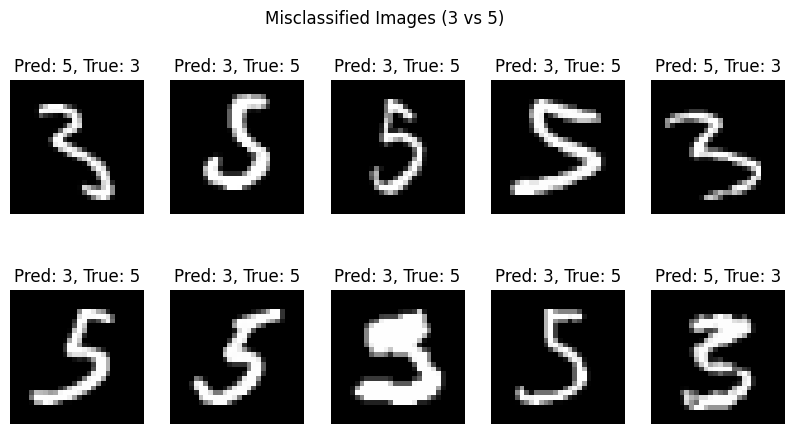

In [20]:
# Predict and evaluate on 3 vs 5
pred_3_5_scores = np.dot(X_3_5, weights_3_5) + bias_3_5
y_pred_3_5 = np.where(pred_3_5_scores >= 0, 1, 0)

# Map {0,1} predictions back to actual labels {3,5}
label_map = np.where(y_pred_3_5 == 0, 3, 5)
final_accuracy_3_5 = np.mean(label_map == y_3_5)
print(f"Mapped Accuracy for 3 vs 5: {final_accuracy_3_5:.4f}")

misclassified_idx_3_5 = np.where(label_map != y_3_5)[0]

if len(misclassified_idx_3_5) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx_3_5[:10]):
        ax.imshow(X_3_5[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {label_map[idx]}, True: {y_3_5[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.show()
else:
    print("All images were correctly classified for 3 vs 5!")

### Conclusion (3 vs 5)

- The perceptron provides a linear decision boundary, so it can classify many 3/5 digits correctly but may still misclassify ambiguous shapes.
- Misclassified images usually contain writing styles where 3 and 5 share similar stroke patterns.
- This demonstrates both the usefulness and limitation of a single-layer perceptron on harder digit pairs.